Code for only running autoencoder bootstrap iteration sweep in Colab -> GCS 
#### changelog 
+ v2- successfully runnig N iterations across all combinations
+ v3- adding WT CLNZ and streamlinecode. created N indepdenent bootstrap run code to evaluate staiblity of results. packaged resample function

In [1]:
!ls 


 autoencoder_cloud_requirements.txt
 ax_modifier_functions_cloud.py
 class_matrix_results
 CLAUDE.md
 cloud_storage.py
 data
'DB index mean diff cohen_d posthoc test.csv'
 desktop.ini
 external_functions.py
 LICENSE
 lightning_autoencoder.code-workspace
 output
 paper_plot.mplstyle
 __pycache__
 README.md
 sample_data
 service_account_key.json
 sns_plotting_config.py


In [2]:
2

2

In [3]:
# Shim for Python 3.12 which removed the 'imp' module
import importlib, types, sys
imp_shim = types.ModuleType('imp')
imp_shim.reload = importlib.reload
sys.modules['imp'] = imp_shim

%load_ext autoreload
%autoreload 2
%pip install -r autoencoder_cloud_requirements.txt
# %pip install -r autoencoder_cloud_requirements.txt -v 2>&1 | grep -E "Building|Successfully"
%matplotlib inline
import sys
import os
import logging #to suppress pytorch GPU output etc
import warnings
#supress specific future warnings and automatic lighitning outputs
logging.getLogger("lightning.pytorch.utilities.rank_zero").setLevel(logging.FATAL)
logging.getLogger("pytorch_lightning.utilities.rank_zero").setLevel(logging.WARNING)
warnings.filterwarnings(action='ignore', category=FutureWarning)
warnings.filterwarnings("ignore",r".*does not have many workers which may be a bottleneck.*")
warnings.filterwarnings("ignore",".*GPU available.*",category=UserWarning) # option 2: just filter out the GPU‐warning
#run import modules for analysis 
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import pandas as pd
import seaborn as sns
import itertools
from tqdm import tqdm
import datetime
import pickle
import sklearn
from sklearn.metrics import davies_bouldin_score
print(f"matplotlib version: {matplotlib.__version__},sns version: {sns.__version__},pandas ver: {pd.__version__}")
#torch imports
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import lightning as L
from torch.utils.data import TensorDataset, DataLoader
from functools import partial
from joblib import Parallel, delayed 

#custom loads
from cloud_storage import save_to_gcs, load_parquet_from_gcs
from external_functions import *
from sns_plotting_config import *
from ax_modifier_functions_cloud import *
plt.style.use('paper_plot.mplstyle')
#colab kernel fixes 
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']  # Available on Colab
plt.rcParams['font.family'] = 'sans-serif'
## elsevier fig sizes https://www.elsevier.com/about/policies-and-standards/author/artwork-and-media-instructions/artwork-sizing

matplotlib version: 3.10.0,sns version: 0.13.2,pandas ver: 2.2.2


<Figure size 640x480 with 0 Axes>

In [4]:
# # Define the relative path to the src directory
# module_path = r'G:\My Drive\Colab notebooks\Function .py Storage\plot_posthoc_test\src\plot_posthoc_test'
# function_dir =  os.path.join(r'G:\\My Drive\\Colab notebooks\\', 'Function .py Storage')
# print(function_dir)
# if module_path not in sys.path:
#     sys.path.append(module_path)
# if function_dir not in sys.path:
#     sys.path.append(function_dir)
# # Import functions and classes from plot_stat_annotate
# from plot_stat_annotate import *



In [5]:
print(os.getcwd())

/content


## Process Data 


#### Create dataset object for resampling in bootstrapabs

In [6]:
folder_loc = '/Run Outputs/'
date_tag = "_".join([datetime.now().strftime('%d'),datetime.now().strftime('%h'),datetime.now().strftime('%Y')])
print(f"date tag: {date_tag}")
folder_name =folder_loc+  f"figure_5_postSVM_decoding_accuracy_and_PCA_plots_"+ date_tag + "/"

date tag: 12_Feb_2026


In [7]:
# new folder structure:
# outputs/                     # For trained models and results
# │   ├── models/                  # Trained model checkpoints
# │   ├── figures/                 # Generated figures
# │   └── logs/                    # Lightning logs
    
data_folder = os.getcwd() +"/data/"
output_folder = os.getcwd() +"/output/"
model_results_folder = output_folder + "/model_results/"
current_run_output = model_results_folder + f"{date_tag}\\"
all_figure_output_folder = output_folder +"/figures/"
fig_output = all_figure_output_folder + f"{date_tag}\\"
#make folders 
make_folder(output_folder)
make_folder(all_figure_output_folder)
make_folder(fig_output)
make_folder(model_results_folder)
make_folder(current_run_output)

'/content/output//model_results/12_Feb_2026\\'

In [8]:
# new_trial_df_filename = r"python-made_trial_timeseries_raster_2025-12-21 12.parquet"
new_trial_df_filename = r'matlab-made_trial_timeseries_normalized_2026-01-31 17.parquet'
use_new_dataset = True
if use_new_dataset:
    #if data is from new_dataset
    subject_col = 'subject_name'
    unit_ID_col = 'neuron_ID'
else: 
    #if data is from old dataset:
    subject_col = 'name'
    unit_ID_col = 'unique_ID'
    
#declare loc/names of files to read
load_dataset = True
save_norm_trial_dataset = True
# trial_df_filename = data_folder +  f"Dlx56_Normalized Trial Calcium Timeseries_20_Jun_2025.parquet"
trial_df_filename = data_folder +  new_trial_df_filename
if load_dataset:
    print(f"loading_dataset")
    trial_tseries_df_norm = pd.read_parquet(trial_df_filename)
trial_tseries_df_norm.tail()

loading_dataset


,task_phase_vec,IA_RS_vec,corr_err_vec,trial_num,neuron_ID,section,subject_name,session,raw_ID,day,...,pvalue_post_outcome_Late_RS,Run_end_time,num_shuffles,any_enrichment,enriched_in_phase,normalized,max_trial_val_all_time,min_max_type,mean_rate_in_trial,cell_is_active_in_trial
116370,Late_RS,RS,Correct,38,9_3_HET_RS3-209,post_outcome,9_3_HET_RS3,RS3,209,3,...,0.4277,30-Jan-2026 17:20:28,10000,1.0,False,none,1.0,all_frames,0.0150,True
116373,Late_RS,RS,Correct,38,9_3_HET_RS3-212,post_outcome,9_3_HET_RS3,RS3,212,3,...,0.4392,30-Jan-2026 17:20:28,10000,2.0,False,none,1.0,all_frames,0.0225,True
116374,Late_RS,RS,Correct,38,9_3_HET_RS3-213,post_outcome,9_3_HET_RS3,RS3,213,3,...,1.0000,30-Jan-2026 17:20:28,10000,0.0,False,none,1.0,all_frames,0.0000,False
116375,Late_RS,RS,Correct,38,9_3_HET_RS3-214,post_outcome,9_3_HET_RS3,RS3,214,3,...,0.0483,30-Jan-2026 17:20:28,10000,1.0,True,none,1.0,all_frames,0.1500,True
116376,Late_RS,RS,Correct,38,9_3_HET_RS3-215,post_outcome,9_3_HET_RS3,RS3,215,3,...,0.1055,30-Jan-2026 17:20:28,10000,0.0,False,none,0.8,all_frames,0.0000,False


In [9]:
#once loaded, derive info from metadata
stage_names = sorted(trial_tseries_df_norm['task_phase_vec'].unique())#hardcode the stage_names (to not rely on the order of the 'unique() vector of the df
numeric_col = get_numeric_cols_timeseries(trial_tseries_df_norm, " to ") #in external_functions.py
# note informative stats for refernce later if necessary
subject_stage_info_df = get_subject_stage_info_df(trial_tseries_df_norm, cell_id_name_col = unit_ID_col, subj_name_col = 'subject_name')#.rename({unit_ID_col: "unique_ID"},axis = 1) # get subj level dfs
n_total_units = trial_tseries_df_norm.groupby(by = 'geno_day')[unit_ID_col].nunique()
print(n_total_units)
print(n_total_units.sum())
subject_stage_info_df.tail()

geno_day
Het CLNZ         866
Het VEH          874
Het postCLNZ     937
WT CLNZ         1019
WT VEH          1080
Name: neuron_ID, dtype: int64
4776


,subject_name,geno_day,task_phase_vec,neuron_ID,num_enriched_units,num_units,trial_num,count_of_trials,over_5
198,9_3_HET_RS3,Het postCLNZ,Early_IA_Error,"[9_3_HET_RS3-6, 9_3_HET_RS3-9, 9_3_HET_RS3-12,...",35,179,"[3, 5]",2,"[False, False]"
199,9_3_HET_RS3,Het postCLNZ,Early_RS_Correct,"[9_3_HET_RS3-40, 9_3_HET_RS3-62, 9_3_HET_RS3-7...",10,179,"[17, 19, 21]",3,"[True, True, True]"
200,9_3_HET_RS3,Het postCLNZ,Early_RS_Error,"[9_3_HET_RS3-25, 9_3_HET_RS3-45, 9_3_HET_RS3-6...",8,179,"[18, 20]",2,"[True, True]"
201,9_3_HET_RS3,Het postCLNZ,Late_IA,"[9_3_HET_RS3-4, 9_3_HET_RS3-9, 9_3_HET_RS3-25,...",15,179,"[12, 13, 14, 15, 16]",5,"[True, True, True, True, True]"
202,9_3_HET_RS3,Het postCLNZ,Late_RS,"[9_3_HET_RS3-3, 9_3_HET_RS3-130, 9_3_HET_RS3-214]",3,179,"[34, 35, 36, 38]",4,"[True, True, True, True]"


#### save class matrix store for loading later

In [10]:
# ## helper functions imported from phase_enrich_timeseries_decode.py module
def get_dataset_names_in_geno(dataset_name_by_geno_day,
                              geno_day,
                              subject_name_col = 'subject_name'):
    datasets_in_geno = dataset_name_by_geno_day.loc[dataset_name_by_geno_day.geno_day == geno_day,subject_name_col].values[0] #get name of datasets in current geno_day setup
    return datasets_in_geno

 ## imported subfunc for cuDF speedup
def get_tseries_of_dataset(timeseries_df, 
                           dataset_name, 
                           subject_name_col = 'subject_name'):
    #get time-series that are occurign in phase of interest
    dataset_df_slice = timeseries_df.loc[timeseries_df[subject_name_col] == dataset_name]
    return dataset_df_slice

def get_tseries_in_phase(timeseries_df, phase_name):
    phase_dataset_df_slice = timeseries_df.loc[timeseries_df.task_phase_vec == phase_name]
    return phase_dataset_df_slice

def get_tseries_phase_enrich_cells(tseries_df, unit_ID_col, enrichment_ID_df, dataset_name, e_phase_name):
    enrich_in_phase_unit_IDs = get_dataset_units_enrich_in_phase(enrichment_ID_df, unit_ID_col, dataset_name, e_phase_name) #get unit IDs that are enriched in phase of interest
    enrich_in_phase_dataset_df = tseries_df.loc[tseries_df[unit_ID_col].isin(enrich_in_phase_unit_IDs)]#get unit time-series only if they enriched in phase of interest
    return enrich_in_phase_dataset_df, enrich_in_phase_unit_IDs

def get_dataset_units_enrich_in_phase(enrich_unit_by_name_phase_df,
                                       unit_ID_col,
                                         dataset_name,
                                           stage_of_interest,
                                           subject_name_col = 'subject_name'):
    name_mask = enrich_unit_by_name_phase_df[subject_name_col] == dataset_name
    phase_mask = enrich_unit_by_name_phase_df.task_phase_vec == stage_of_interest
    enrich_in_phase_unit_IDs =enrich_unit_by_name_phase_df.loc[phase_mask&name_mask, unit_ID_col].values[0]
    return enrich_in_phase_unit_IDs

def horzcat_all_trials(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col]
    grouped = {
        trial: group.set_index(unit_col_name)[tseries_cols]
        for trial, group in timeseries_df.groupby('trial_num', sort=False)
    }
    return pd.concat(grouped.values(), axis=1)

In [11]:
def horzcat_all_trials_original(timeseries_df, tseries_cols, unit_col_name, drop_pre_outcome=None):
    if drop_pre_outcome:
        tseries_cols = [col for col in tseries_cols if "-" not in col] 
    trial_slice_storage = []
    for trial in timeseries_df.trial_num.unique():
        trial_slice = timeseries_df.loc[timeseries_df.trial_num == trial].set_index(unit_col_name)
        trial_slice_storage.append(trial_slice.loc[:,tseries_cols])
    return pd.concat(trial_slice_storage, axis=1)



# Test
result_orig = horzcat_all_trials_original(trial_tseries_df_norm, numeric_col,unit_ID_col)
result_opt = horzcat_all_trials(trial_tseries_df_norm, numeric_col,unit_ID_col)

print("Identical:", result_orig.equals(result_opt))
print("Shape match:", result_orig.shape == result_opt.shape)
print("Columns match:", list(result_orig.columns) == list(result_opt.columns))
print("Index match:", list(result_orig.index) == list(result_opt.index))

Identical: True
Shape match: True
Columns match: True
Index match: True


In [12]:
def make_dataset_matrix_store_only(phase_names, 
                                   trial_tseries_df_norm,
                                   unit_ID_col,
                                   enrich_unit_ID_by_name_df,
                                    numeric_col,
                                    trial_list_by_dataset,
                                   dataset_name_by_geno_day,
                                   phase_enrichment_by_subj,
                                     subject_name_col = 'subject_name'):
    """TO- create a dict where key1 = stage the pseudopop is enriched in, key 2 = stage to look for activity of, and key 3- genotype of current datset"""
    ppop_data,stage_geno_tseries = dict(), dict()
    iter_ct = 0
    for e_phase in phase_names:
        ppop_data[e_phase],stage_geno_tseries[e_phase] = {},{}
        print("Get enrich in ",e_phase, "act. in ", phase_names)

        for act_phase in phase_names:
            datasets_w_phase_act = trial_list_by_dataset.loc[trial_list_by_dataset.task_phase_vec == act_phase][subject_name_col].unique()
            ppop_data[e_phase][act_phase],stage_geno_tseries[e_phase][act_phase]= {},{}

            for geno_day in dataset_name_by_geno_day.geno_day.unique():
                datasets_in_geno = get_dataset_names_in_geno(dataset_name_by_geno_day,geno_day)
                geno_dataset_w_act = [name for name in datasets_in_geno if name in datasets_w_phase_act]
                current_ppop_draw = dict()
                
                for dataset in geno_dataset_w_act:
                    iter_ct = iter_ct+1
                    #check if > 0 cells are enriched in stage
                    if phase_enrichment_by_subj.set_index(subject_name_col).loc[dataset, e_phase] > 0:
                        phase_dataset_df = get_tseries_in_phase(get_tseries_of_dataset(trial_tseries_df_norm,dataset), act_phase)
                        e_in_phase_data_df,e_in_stage_ID =get_tseries_phase_enrich_cells(phase_dataset_df, unit_ID_col,
                                                                                         enrich_unit_ID_by_name_df, dataset, e_phase)
                        current_ppop_draw[dataset] =  horzcat_all_trials(e_in_phase_data_df,numeric_col, unit_ID_col)
                ppop_data[e_phase][act_phase][geno_day] =current_ppop_draw
    return ppop_data

In [13]:
from google.oauth2 import service_account
from googleapiclient.discovery import build
from googleapiclient.http import MediaFileUpload

lightning_autoencoder_googleID = '1D6Vg0uPWJD4hHEaS4nDtFPNBoWZY2ovN'
# ============ SETUP (run once per session) ============
SCOPES = ['https://www.googleapis.com/auth/drive']
SERVICE_ACCOUNT_FILE = 'service_account_key.json'
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
drive_service = build('drive', 'v3', credentials=creds)
drive_service

In [14]:

def save_to_drive(local_path, drive_filename, folder_id=None):
    """Upload file to Google Drive. Optionally specify a folder ID."""
    if not os.path.exists(local_path):
        print(f"Warning: {local_path} does not exist, skipping upload")
        return None
    metadata = {'name': drive_filename}
    if folder_id:
        metadata['parents'] = [folder_id]
    media = MediaFileUpload(local_path)
    file = drive_service.files().create(body=metadata,
                                        media_body=media,
                                        fields='id',
                                        supportsAllDrives=True).execute()
    # Transfer ownership to your personal account
    drive_service.permissions().create(
        fileId=file_id,
        transferOwnership=True,
        body={'type': 'user', 'role': 'owner',
               'emailAddress': "13carlosj@gmail.com"}).execute()
    print(f"Saved to Drive: {drive_filename}")
    file_id = file.get('id')


    return 

def create_drive_folder(folder_name, parent_id=None):
    metadata = {
        'name': folder_name,
        'mimeType': 'application/vnd.google-apps.folder'
    }
    if parent_id:
        metadata['parents'] = [parent_id]
    folder = drive_service.files().create(body=metadata, fields='id').execute()
    return folder.get('id')

# # In your training loop:
# pd.concat(bootstrap_storage).to_parquet(checkpoint_file)
# save_to_drive(checkpoint_file, f"bootstrap_checkpoint_{date_tag}.parquet")

In [15]:
from google.cloud import storage

client = storage.Client.from_service_account_json('service_account_key.json')
bucket = client.bucket('colab_autoencoder_output')

def save_to_gcs(local_path, blob_name):
    blob = bucket.blob(blob_name)
    blob.upload_from_filename(local_path)
    print(f"Uploaded: gs://colab_autoencoder_output/{blob_name}")

# Test it
save_to_gcs('/content/README.md', 'README.md')

Uploaded: gs://colab_autoencoder_output/README.md


In [16]:
local_colab_folder = os.getcwd() + "/class_matrix_results/"
#make folders 
make_folder(local_colab_folder)

'/content/class_matrix_results/'

In [17]:
# save store class_matrix_store
class_matrix_save_file =  f"pseudopop_ensemble_activity_dict_{date_tag}.pickle"
load_filename = data_folder + f"pseudopopulation_ensemble_activity_store_20_Jun_2025.pickle"

#set options
make_class_matrix = True
save_class_matrix = True
write_to_GCS = True
neuron_ID_col = unit_ID_col
#set loop
if make_class_matrix: ##create class matrix store
    #extract enrichment to see what subjects had 0 enriched cells 
    neuron_enrichment =  trial_tseries_df_norm.groupby(['subject_name', 'geno_day', unit_ID_col])[stage_names].mean().reset_index()
    phase_enrichment_by_subj = neuron_enrichment[list(stage_names) + ['subject_name', 'geno_day']].groupby(by = ['subject_name', 'geno_day']).sum().reset_index()
    
    #filter by subjects with > 1 trial in a given stage 
    trial_list_by_dataset= subject_stage_info_df.loc[:,['subject_name', 
                                                        'geno_day', 'task_phase_vec', 'trial_num', 'count_of_trials']]
    trial_list_by_dataset= trial_list_by_dataset[trial_list_by_dataset.count_of_trials >1]##important- threshold to take datasets with >1 trials per section (to have enough variety in neural activity)
    enrich_unit_ID_by_name_df = subject_stage_info_df.loc[:,['subject_name', 'geno_day', 'task_phase_vec', neuron_ID_col]]
    dataset_name_by_geno_day = enrich_unit_ID_by_name_df.groupby('geno_day')['subject_name'].unique().reset_index()
    
    #use premade information to create new matrix
    class_matrix_store = make_dataset_matrix_store_only(stage_names,
                                                        trial_tseries_df_norm,
                                                        unit_ID_col = neuron_ID_col,
                                                        enrich_unit_ID_by_name_df = enrich_unit_ID_by_name_df, 
                                                        numeric_col = numeric_col,
                                                        trial_list_by_dataset = trial_list_by_dataset,
                                                        dataset_name_by_geno_day = dataset_name_by_geno_day,
                                                        phase_enrichment_by_subj = phase_enrichment_by_subj)
    if save_class_matrix:
        print(f"Saving {class_matrix_save_file}")
        with open(local_colab_folder + class_matrix_save_file, 'wb') as handle:
            pickle.dump(class_matrix_store, handle, protocol=pickle.HIGHEST_PROTOCOL)
            if write_to_GCS:
                print(f"Writing to CGS: {class_matrix_save_file}")
                save_to_gcs(local_colab_folder + class_matrix_save_file, local_colab_folder + class_matrix_save_file)
else: #if you don't make or save one, you load one 
    print(f" loading file: {load_filename}")
    with open(load_filename, 'rb') as handle:
        class_matrix_store = pickle.load(handle)

Get enrich in  Early_IA_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_IA_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Correct act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Early_RS_Error act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_IA act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Get enrich in  Late_RS act. in  ['Early_IA_Correct', 'Early_IA_Error', 'Early_RS_Correct', 'Early_RS_Error', 'Late_IA', 'Late_RS']
Saving pseudopop_ensemble_activity_dict_12_Feb_2026.pickle
Writing to CGS: pseudopop_ensemble_activity_dict_12_Feb_2026.pickle
Uploaded: gs://colab_autoencoder_output//content/class_

## Test Pytorch Lightning Autoencoder function on sample data 

#### Define pytorch lightining functions

In [18]:
## separate into function 
def return_train_test_tensorDataset(input_data, input_labels:np.array, shuffle:bool = True, test_on_train:bool = True):
    '''TO- given numpy matrices, and optional shuffle, return 2 pytorch test and train datasets in tensor format'''
    #moved from outside func to inside
    input_data = input_data.values.T #.T.values of concat matrix is to reshape mat into what scikit wants from you
    #get indices
    assert input_data.shape[0] > 0
    rng = np.random.default_rng()
    n_samples = input_data.shape[0]
    input_data_index =np.arange(0,n_samples) 
    permuted_index = rng.permutation(input_data_index)

    if test_on_train:
        if shuffle:
            train_index = permuted_index
            test_index = permuted_index
        else: #non shuffle, test set = train set
            train_index = input_data_index
            test_index = train_index
    else: #if test not == train
        if shuffle:
            train_index = permuted_index[0:n_samples//2]
            test_index = permuted_index[n_samples//2:n_samples]
        else:
            train_index = input_data_index[0:n_samples//2]
            test_index =  input_data_index[n_samples//2:n_samples]
        
    ##extract data of interest 
    train_data= torch.tensor(input_data[train_index,:], dtype=torch.float32)
    train_labels= torch.tensor(input_labels[train_index], dtype=torch.float32)
    
    test_data = torch.tensor(input_data[test_index,:], dtype=torch.float32)
    test_labels = torch.tensor(input_labels[test_index], dtype=torch.float32)
    ## consolidate into TEnsorDataset objects
    train_dataset = TensorDataset(train_data, train_labels)
    test_dataset = TensorDataset(test_data, test_labels)
    
    return train_dataset, test_dataset

In [19]:
weight_decay = 1e-2
class dropout_net(nn.Module):
    def __init__(self, layer_1_input=50, bottleneck_input = 9, latent_space_size = 2,dropout= 0):
        super().__init__()
        ### Using a bottleneck latent dimension of 2
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input,bottleneck_input),nn.Mish(),nn.Dropout(dropout),nn.Linear(bottleneck_input, latent_space_size)) #from 250 node layer to 3D bottle neck/ latent space 
        self.decoder = nn.Sequential(
            nn.Linear(latent_space_size,bottleneck_input),nn.Mish(),nn.Linear(bottleneck_input, layer_1_input))

    def forward(self, x):      
        x = self.encoder(x)
        x = self.decoder(x)
        return x

# define the LightningModule
class LitAutoEncoder(L.LightningModule):
    def __init__(self, dropout_net, **model_kwargs):#load/import  model 
        super().__init__()
        self.save_hyperparameters()# save hyperparameters to self.hparams
        self.model = dropout_net(**model_kwargs)# instantiate your model
        
    def configure_optimizers(self):
        #NEW using  weight decay baked into AdamW
        optimizer = optim.AdamW(self.parameters(),weight_decay = weight_decay, lr=0.0125)### Define your loss function (training criterion). tempw as at 0.0125, reset to 0.013
        return optimizer 
 # training_step of the LightningModule configure how your training routine behaves with a batch of training data:      
    def training_step(self, batch, batch_index):
        (data, target) = batch #unpack traiing data 
        output = self.forward(data) #get reconstruction output of model
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)# logs metrics for each training_step, & the average across the epoch, to the progress bar and logger
        return loss
    
    def forward(self, x):
        # here you define how to get outputs from inputs
        return self.model(x)

    def encode(self, x):
        # directly reach into the wrapped nn.Module
        return self.model.encoder(x)

In [20]:
class LossHistory(L.Callback):
    ## class used to store loss history of trainer module through callbacks to the trainer
    def __init__(self):
        super().__init__()
        self.train_losses = []

    def on_train_epoch_end(self, trainer, pl_module):        # pl_module.log(..., on_epoch=True) ensures 'train_loss' is in callback_metrics
        loss = trainer.callback_metrics.get("train_loss")
        if loss is not None: # .item() to turn it into a Python float
            self.train_losses.append(loss.item())

    def on_validation_epoch_end(self, trainer, pl_module):
        loss = trainer.callback_metrics.get("val_loss")
        if loss is not None:
            self.val_losses.append(loss.item())

In [21]:
def lightning_encode(model, test_loader):
    ### Push data into latent space without retreiving
    model.freeze()
    latent =[]
    labels = []
    # device = next(model.parameters()).device
    # print("Model is on:", device)
    for batch_idx, (data, target) in enumerate(test_loader): #target is true labels y
        latentSpace = model.encode(data)
        #store results
        latent.append(latentSpace.detach().numpy())
        labels.append(target.detach().numpy())
    return np.vstack(latent),  np.hstack(labels) # this should match the dim of latent_embeddings, so each pair of coordinates has an associated label

#### Test sample model performance on pytorch lightning

## Hyperparameter Sweep: Activation Functions & Hidden Layer Sizes

Sweep over:
- **Activation functions**: ReLU, Leaky ReLU, Mish
- **Hidden layer sizes**: 2, 3, 4, 5 units

In [22]:
# Flexible autoencoder with configurable activation function
ACTIVATION_MAP = {
    'relu': nn.ReLU,
    'leaky_relu': nn.LeakyReLU,
    'mish': nn.Mish,
}

class FlexibleAutoEncoder(nn.Module):
    """Autoencoder with configurable activation function and hidden layer size."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, latent_space_size=2, 
                 dropout=0, activation='mish'):
        super().__init__()
        activation_fn = ACTIVATION_MAP.get(activation, nn.Mish) #if not specified, return use mish
        
        self.encoder = nn.Sequential(
            nn.Linear(layer_1_input, bottleneck_input),
            activation_fn(),
            nn.Dropout(dropout),
            nn.Linear(bottleneck_input, latent_space_size)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_space_size, bottleneck_input),
            activation_fn(),
            nn.Linear(bottleneck_input, layer_1_input)
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x


class LitFlexibleAutoEncoder(L.LightningModule):
    """Lightning wrapper for FlexibleAutoEncoder with configurable hyperparameters."""
    def __init__(self, layer_1_input=50, bottleneck_input=9, latent_space_size=2,
                 dropout=0, activation='mish', lr=0.0125, weight_decay=1e-2):
        super().__init__()
        self.save_hyperparameters()
        self.model = FlexibleAutoEncoder(
            layer_1_input=layer_1_input,
            bottleneck_input=bottleneck_input,
            latent_space_size=latent_space_size,
            dropout=dropout,
            activation=activation
        )
        self.lr = lr
        self.weight_decay = weight_decay
        
    def configure_optimizers(self):
        return optim.AdamW(self.parameters(), weight_decay=self.weight_decay, lr=self.lr)
    
    def training_step(self, batch, batch_index):
        data, target = batch
        output = self.forward(data)
        loss = F.mse_loss(output, data)
        self.log("train_loss", loss, on_step=True, on_epoch=True, prog_bar=True, logger=True)
        return loss
    
    def forward(self, x):
        return self.model(x)

    def encode(self, x):
        return self.model.encoder(x)

In [23]:
comparison = 'Early_IA_Error_v_Early_RS_Error'
ensemble = 'Early_RS_Error'
n_frames_to_draw = 400
n_epochs = 50
n_bootstrap = 100  # number of bootstrap iterations per hyperparameter combo
BATCH_SIZE = 500
val_fraction = 0.5  # fraction of frames held out for validation set
val_seed = 42       # seed for sanity-check cell only; sweep uses iteration index as seed

# Prepare data for the sweep (using first genotype as test case)
geno = geno_order[0]  # 'WT VEH'
# class_0, class_1 = comparison.split("_v_")

sweep_config = {
    'activations': ['relu', 'leaky_relu', 'mish'],
    'hidden_sizes': [2, 3, 4, 5],
}

print(f"Sweep configuration:")
print(f"  Comparison: {comparison}")
print(f"  Ensemble: {ensemble}")
print(f"  Frames to draw: {n_frames_to_draw}")
print(f"  Epochs: {n_epochs}")
print(f"  Activations: {sweep_config['activations']}")
print(f"  Hidden sizes: {sweep_config['hidden_sizes']}")
print(f"  Bootstrap iterations: {n_bootstrap}")
print(f"  Validation fraction: {val_fraction}")
print(f"  Total combinations: {len(sweep_config['activations']) * len(sweep_config['hidden_sizes'])}")

Sweep configuration:
  Comparison: Early_IA_Error_v_Early_RS_Error
  Ensemble: Early_RS_Error
  Frames to draw: 400
  Epochs: 50
  Activations: ['relu', 'leaky_relu', 'mish']
  Hidden sizes: [2, 3, 4, 5]
  Bootstrap iterations: 100
  Validation fraction: 0.5
  Total combinations: 12


In [24]:
geno_order

['WT VEH', 'Het VEH', 'Het CLNZ', 'Het postCLNZ']

In [25]:
def split_frame_pools(class_matrix_store, ensemble, stages, geno_list,
                      val_fraction=0.3, seed=42, verbose=True):
    """Split frames in class_matrix_store into train and validation pools.
    
    For each subject's activity DataFrame, randomly assigns columns (frames)
    to either the train pool (1 - val_fraction) or validation pool (val_fraction)
    using a fixed seed for reproducibility.
    
    Returns two dicts with the same nesting structure as class_matrix_store
    so existing resampling functions work unchanged on the train store.
    """
    rng = np.random.default_rng(seed)
    train_store = {ensemble: {}}
    val_store = {ensemble: {}}
    
    for stage in stages:
        train_store[ensemble][stage] = {}
        val_store[ensemble][stage] = {}
        
        for geno in geno_list:
            activity_dict = class_matrix_store[ensemble][stage][geno]
            train_dict = {}
            val_dict = {}
            
            for subject, df in activity_dict.items():
                n_frames = df.shape[1]
                n_val = max(1, int(n_frames * val_fraction))
                perm = rng.permutation(n_frames)
                
                # Use iloc for positional selection — df.columns has duplicate
                # time-bin names from horzcat_all_trials, so label-based
                # selection (df[df.columns[...]]) would match ALL columns
                # with that name, breaking the split.
                val_dict[subject] = df.iloc[:, perm[:n_val]]
                train_dict[subject] = df.iloc[:, perm[n_val:]]
            
            train_store[ensemble][stage][geno] = train_dict
            val_store[ensemble][stage][geno] = val_dict
    
    if verbose:
        # Print summary
        for geno in geno_list:
            for stage in stages:
                train_frames = sum(df.shape[1] for df in train_store[ensemble][stage][geno].values())
                val_frames = sum(df.shape[1] for df in val_store[ensemble][stage][geno].values())
                print(f"  {geno} \ {stage}: {train_frames} train frames, {val_frames} val frames")
        
        # Sanity check: verify split is correct and no data leakage
        print("\n  Split sanity check:")
        for geno in geno_list:
            for stage in stages:
                for subj in train_store[ensemble][stage][geno]:
                    orig = class_matrix_store[ensemble][stage][geno][subj]
                    tr = train_store[ensemble][stage][geno][subj]
                    va = val_store[ensemble][stage][geno][subj]
                    assert tr.shape[1] + va.shape[1] == orig.shape[1], (
                        f"Frame count mismatch for {subj}\{stage}\{geno}: "
                        f"train({tr.shape[1]}) + val({va.shape[1]}) != orig({orig.shape[1]})"
                    )
                total_orig = sum(df.shape[1] for df in class_matrix_store[ensemble][stage][geno].values())
                train_frames = sum(df.shape[1] for df in train_store[ensemble][stage][geno].values())
                val_frames = sum(df.shape[1] for df in val_store[ensemble][stage][geno].values())
                print(f"    {geno}\{stage}: orig={total_orig}, train+val={train_frames}+{val_frames}={train_frames+val_frames} ✓" 
                      if total_orig == train_frames + val_frames 
                      else f"    {geno}\{stage}: MISMATCH orig={total_orig} != {train_frames+val_frames}")
    
    return train_store, val_store


def build_validation_loader(val_store, ensemble, class_0, class_1, geno, batch_size,
                            n_val_resample=500, val_resample_seed=123):
    """Build a validation DataLoader from held-out validation frames.
    
    Resamples val frames to a fixed count using a seeded rng (same approach as
    the training path via resample_combine_dict_of_activity_dfs), ensuring:
    - Equal-width DataFrames with integer columns for clean pd.concat
    - Consistent with how training data is prepared
    
    Returns (val_loader, n_val_cells).
    """
    val_rng = np.random.default_rng(val_resample_seed)
    
    val_class_0 = resample_combine_dict_of_activity_dfs(
        val_store[ensemble][class_0][geno], n_val_resample, val_rng
    )
    val_class_1 = resample_combine_dict_of_activity_dfs(
        val_store[ensemble][class_1][geno], n_val_resample, val_rng
    )
    
    val_concat, val_labels = fast_pack_data_local(val_class_0, val_class_1, 0, 1)
    n_val_cells = val_concat.shape[0]
    
    # Transpose to (frames, neurons) for PyTorch convention
    val_data = torch.tensor(val_concat.values.T, dtype=torch.float32)
    val_labels_tensor = torch.tensor(val_labels, dtype=torch.float32)
    
    val_dataset = TensorDataset(val_data, val_labels_tensor)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, 
                            shuffle=False, num_workers=0)
    
    return val_loader, n_val_cells


def train_single_sweep_model(n_cells, train_loader, val_loader,
                              activation, latent_space_size, n_epoch=50, dropout=0):
    """Train a single model and evaluate on both training and validation data.
    
    Returns dict with train_loss, train_db_index, val_loss, val_db_index.
    """
    model = LitFlexibleAutoEncoder(
        layer_1_input=n_cells,
        bottleneck_input=9,
        latent_space_size=latent_space_size,
        dropout=dropout,
        activation=activation
    )
    
    history = LossHistory()
    trainer = L.Trainer(
        enable_model_summary=False,
        enable_progress_bar=False,
        accelerator="cpu",
        enable_checkpointing=False,
        max_epochs=n_epoch,
        log_every_n_steps=2,
        callbacks=[history],
    )
    trainer.fit(model, train_loader)
    
    train_loss = history.train_losses[-1] if history.train_losses else np.nan
    model.freeze()
    
    with torch.no_grad():
        # Train metrics
        train_embed, train_labels = lightning_encode(model, train_loader)
        train_db_index = davies_bouldin_score(train_embed, train_labels)
        
        # Validation metrics
        val_embed, val_labels = lightning_encode(model, val_loader)
        val_db_index = davies_bouldin_score(val_embed, val_labels)
        
        # Validation reconstruction loss
        val_loss_accum = []
        for data, target in val_loader:
            output = model(data)
            val_loss_accum.append(F.mse_loss(output, data).item())
        val_loss = np.mean(val_loss_accum)
    
    return {
        'train_db_index': train_db_index,
        'train_loss': train_loss,
        'val_db_index': val_db_index,
        'val_loss': val_loss,
        'activation': activation,
        'hidden_size': latent_space_size,
    }


def run_sweep_bootstrap(class_matrix_store, ensemble, geno_list, comparison,
                        activations, hidden_sizes, n_frames_to_draw=500,
                        n_bootstrap=20, n_epoch=50, batch_size=500,
                        val_fraction=0.5):
    """Run hyperparameter sweep with bootstrap resampling.
    
    Each bootstrap iteration:
    1. Randomly splits frames into train/val pools (fresh partition per iteration).
    2. Resamples training data from the train pool (unseeded).
    3. Resamples validation data from the val pool (seeded per iteration).
    4. All hyperparameter configs train on the same resampled data (paired design).
    """
    class_0, class_1 = comparison.split("_v_")
    stages = [class_0, class_1]
    
    total_combos = len(activations) * len(hidden_sizes)
    total_models = total_combos * n_bootstrap * len(geno_list)
    print(f"Frame split: {1-val_fraction:.0%} train / {val_fraction:.0%} validation (fresh each iteration)")
    print(f"Running sweep: {total_combos} configs x {n_bootstrap} bootstrap "
          f"x {len(geno_list)} genos = {total_models} total models")
    print(f"Each bootstrap: fresh split → resample both pools → train {total_combos} models on same data\n")
    
    # Run one verbose split so the user sees the frame counts
    print("Sample split (iteration 0):")
    split_frame_pools(
        class_matrix_store, ensemble, stages, geno_list, val_fraction, seed=0, verbose=True
    )
    print()
    
    sweep_results = []
    
    for b in tqdm(range(n_bootstrap), desc="Bootstrap", leave=True):
        # Fresh train/val split each iteration
        train_store, val_store = split_frame_pools(
            class_matrix_store, ensemble, stages, geno_list,
            val_fraction, seed=b, verbose=False
        )
        
        for geno in geno_list:
            # Build validation loader from this iteration's val pool
            val_loader, n_val_cells = build_validation_loader(
                val_store, ensemble, class_0, class_1, geno, batch_size,
                n_val_resample=n_frames_to_draw, val_resample_seed=b
            )
            
            # Resample training data from this iteration's train pool
            ensemble_resample = resample_ensemble_stage_activity(
                train_store, n_frames_to_draw, ensemble, geno,
                stages_to_resample=stages
            )
            
            concat_matrix, concat_labels = fast_pack_data_local(
                ensemble_resample[class_0], ensemble_resample[class_1], 0, 1
            )
            
            n_cells = concat_matrix.shape[0]
            assert n_cells == n_val_cells, (
                f"Neuron count mismatch: train={n_cells}, val={n_val_cells}. "
                f"The inner join should produce the same neurons for both."
            )
            
            train_dataset, _ = return_train_test_tensorDataset(
                concat_matrix, concat_labels, shuffle=True
            )
            train_loader = DataLoader(train_dataset, batch_size=batch_size,
                                      shuffle=False, num_workers=0)
            
            # Train ALL configs on the same resampled data
            for activation in activations:
                for hidden_size in hidden_sizes:
                    result = train_single_sweep_model(
                        n_cells, train_loader, val_loader,
                        activation=activation,
                        latent_space_size=hidden_size,
                        n_epoch=n_epoch, dropout=0
                    )
                    result['bootstrap_iter'] = b
                    result['ensemble'] = ensemble
                    result['geno'] = geno
                    result['comparison'] = comparison
                    sweep_results.append(result)
    
    return pd.DataFrame(sweep_results)

<>:46: SyntaxWarning: invalid escape sequence '\ '
<>:57: SyntaxWarning: invalid escape sequence '\{'
<>:57: SyntaxWarning: invalid escape sequence '\{'
<>:63: SyntaxWarning: invalid escape sequence '\{'
<>:65: SyntaxWarning: invalid escape sequence '\{'
<>:46: SyntaxWarning: invalid escape sequence '\ '
<>:57: SyntaxWarning: invalid escape sequence '\{'
<>:57: SyntaxWarning: invalid escape sequence '\{'
<>:63: SyntaxWarning: invalid escape sequence '\{'
<>:65: SyntaxWarning: invalid escape sequence '\{'
/tmp/ipython-input-2173137825.py:46: SyntaxWarning: invalid escape sequence '\ '
  print(f"  {geno} \ {stage}: {train_frames} train frames, {val_frames} val frames")
/tmp/ipython-input-2173137825.py:57: SyntaxWarning: invalid escape sequence '\{'
  f"Frame count mismatch for {subj}\{stage}\{geno}: "
/tmp/ipython-input-2173137825.py:57: SyntaxWarning: invalid escape sequence '\{'
  f"Frame count mismatch for {subj}\{stage}\{geno}: "
/tmp/ipython-input-2173137825.py:63: SyntaxWarning: in

In [26]:
import io
import re
from datetime import datetime
from collections import defaultdict

BUCKET_NAME = 'colab_autoencoder_output'

def list_sweep_folders_gcs(bucket_name=BUCKET_NAME):
    """List all NN_param_sweep folders in GCS bucket, sorted by date (newest first)."""
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    # Find unique sweep folders
    sweep_folders = set()
    for blob in bucket.list_blobs(prefix='/content/NN_param_sweep_'):
        # Extract folder name from blob path
        match = re.match(r'(/content/NN_param_sweep_[^/]+)/', blob.name)
        if match:
            sweep_folders.add(match.group(1))
    
    # Sort by date in folder name (parse date_tag format: DD_Mon_YYYY)
    def parse_folder_date(folder):
        match = re.search(r'NN_param_sweep_(\d{2})_(\w{3})_(\d{4})', folder)
        if match:
            try:
                return datetime.strptime(f"{match.group(1)}_{match.group(2)}_{match.group(3)}", "%d_%b_%Y")
            except ValueError:
                return datetime.min
        return datetime.min
    
    sorted_folders = sorted(sweep_folders, key=parse_folder_date, reverse=True)
    return sorted_folders


def list_parquets_in_folder_gcs(folder_path, bucket_name=BUCKET_NAME):
    """List all parquet files in a GCS folder."""
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    parquet_files = []
    for blob in bucket.list_blobs(prefix=folder_path):
        if blob.name.endswith('.parquet'):
            parquet_files.append({
                'name': blob.name,
                'size_kb': blob.size / 1024 if blob.size else 0,
                'updated': blob.updated
            })
    
    # Sort by update time (newest first)
    parquet_files.sort(key=lambda x: x['updated'] or datetime.min, reverse=True)
    return parquet_files


def load_latest_sweep_from_gcs(bucket_name=BUCKET_NAME, verbose=True):
    """Find the latest NN_param_sweep folder and load all parquets from it."""
    sweep_folders = list_sweep_folders_gcs(bucket_name)
    
    if not sweep_folders:
        print("No NN_param_sweep folders found in GCS bucket.")
        return None, None
    
    if verbose:
        print(f"Found {len(sweep_folders)} sweep folder(s) in gs://{bucket_name}:")
        for i, folder in enumerate(sweep_folders[:5]):  # Show top 5
            print(f"  [{i}] {folder}")
        if len(sweep_folders) > 5:
            print(f"  ... and {len(sweep_folders) - 5} more")
    
    latest_folder = sweep_folders[0]
    if verbose:
        print(f"\nLoading from latest folder: {latest_folder}")
    
    # List parquets in latest folder
    parquet_files = list_parquets_in_folder_gcs(latest_folder, bucket_name)
    
    if not parquet_files:
        print(f"No parquet files found in {latest_folder}")
        return None, latest_folder
    
    if verbose:
        print(f"Found {len(parquet_files)} parquet file(s):")
        for pf in parquet_files:
            updated_str = pf['updated'].strftime('%Y-%m-%d %H:%M') if pf['updated'] else 'N/A'
            print(f"    - {pf['name'].split('/')[-1]} ({pf['size_kb']:.1f} KB, {updated_str})")
    
    # Load and concatenate all parquets
    client = storage.Client.from_service_account_json('service_account_key.json')
    bucket = client.bucket(bucket_name)
    
    dfs = []
    for pf in parquet_files:
        blob = bucket.blob(pf['name'])
        df = pd.read_parquet(io.BytesIO(blob.download_as_bytes()))
        dfs.append(df)
    
    combined_df = pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()
    
    if verbose:
        print(f"\nLoaded {len(combined_df)} total rows from {len(dfs)} file(s)")
    
    return combined_df, latest_folder


In [27]:
!ls

 autoencoder_cloud_requirements.txt
 ax_modifier_functions_cloud.py
 class_matrix_results
 CLAUDE.md
 cloud_storage.py
 data
'DB index mean diff cohen_d posthoc test.csv'
 desktop.ini
 external_functions.py
 LICENSE
 lightning_autoencoder.code-workspace
 output
 paper_plot.mplstyle
 __pycache__
 README.md
 sample_data
 service_account_key.json
 sns_plotting_config.py


  WT VEH \ Early_IA_Error: 288 train frames, 288 val frames
  WT VEH \ Early_RS_Error: 432 train frames, 432 val frames

  Split sanity check:
    WT VEH\Early_IA_Error: orig=576, train+val=288+288=576 ✓
    WT VEH\Early_RS_Error: orig=864, train+val=432+432=864 ✓
Subject: 13_4_WT_RS1 | Stage: Early_IA_Error | Geno: WT VEH
  Original:         (5, 144) (neurons × frames)
  Train pool:       (5, 72)
  Val pool:         (5, 72)
  Train resample:   (5, 400) (from train pool)
  Val resample:     (5, 400) (from val pool, seeded)

  Frame accounting: train(72) + val(72) = 144, original = 144
  ✓ Split is clean: train + val == original frame count


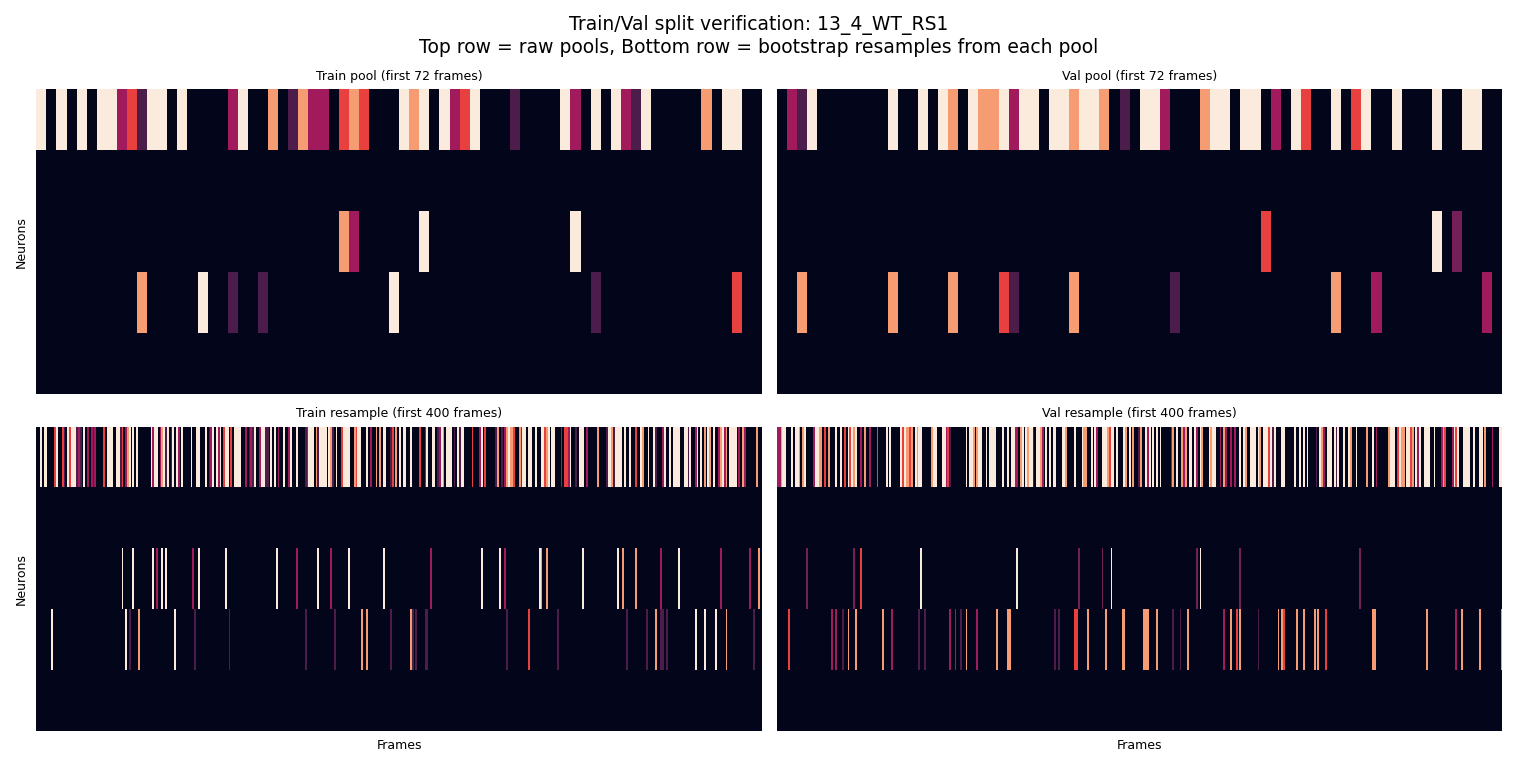

In [28]:
# === Sanity check: visualize train vs val split for one subject ===
# Verify that split_frame_pools produces non-overlapping pools and that
# the resampled validation draw sources from the val pool only.
geno_list = ["WT VEH", "Het VEH"]
_test_geno = geno_list[0]
_class_0, _class_1 = comparison.split("_v_")
_stages = [_class_0, _class_1]

# Run the split
_train_store, _val_store = split_frame_pools(
    class_matrix_store, ensemble, _stages, [_test_geno],
    val_fraction=val_fraction, seed=val_seed
)

# Pick first subject and first stage for visualization
_test_stage = _stages[0]
_test_subj = list(class_matrix_store[ensemble][_test_stage][_test_geno].keys())[0]

_orig = class_matrix_store[ensemble][_test_stage][_test_geno][_test_subj]
_tr = _train_store[ensemble][_test_stage][_test_geno][_test_subj]
_va = _val_store[ensemble][_test_stage][_test_geno][_test_subj]

# Do one seeded resample from the val pool (same as build_validation_loader)
_val_rng = np.random.default_rng(123)
_val_resample = resample_unit_timeseries_df(_va, n_frames_to_draw, _val_rng)

# Do one unseeded resample from the train pool (same as bootstrap training)
_train_resample = resample_unit_timeseries_df(_tr, n_frames_to_draw, np.random.default_rng())

print(f"Subject: {_test_subj} | Stage: {_test_stage} | Geno: {_test_geno}")
print(f"  Original:         {_orig.shape} (neurons × frames)")
print(f"  Train pool:       {_tr.shape}")
print(f"  Val pool:         {_va.shape}")
print(f"  Train resample:   {_train_resample.shape} (from train pool)")
print(f"  Val resample:     {_val_resample.shape} (from val pool, seeded)")

# Plot heatmaps
fig, axes = plt.subplots(2, 2, figsize=(10, 5), layout='constrained')

sns.heatmap(_tr.values[:, :], ax=axes[0, 0], cbar=False, xticklabels=False, yticklabels=False)
axes[0, 0].set_title(f"Train pool (first {_tr.shape[1]} frames)")
axes[0, 0].set_ylabel("Neurons")

sns.heatmap(_va.values[:, :], ax=axes[0, 1], cbar=False, xticklabels=False, yticklabels=False)
axes[0, 1].set_title(f"Val pool (first {_va.shape[1]} frames)")

sns.heatmap(_train_resample.values[:, :], ax=axes[1, 0], cbar=False, xticklabels=False, yticklabels=False)
axes[1, 0].set_title(f"Train resample (first {_train_resample.shape[1]} frames)")
axes[1, 0].set_ylabel("Neurons")
axes[1, 0].set_xlabel("Frames")

sns.heatmap(_val_resample.values[:, :], ax=axes[1, 1], cbar=False, xticklabels=False, yticklabels=False)
axes[1, 1].set_title(f"Val resample (first {_val_resample.shape[1]} frames)")
axes[1, 1].set_xlabel("Frames")

fig.suptitle(f"Train/Val split verification: {_test_subj}\n"
             f"Top row = raw pools, Bottom row = bootstrap resamples from each pool",
             fontsize=9)

# Numerical check: correlation between train and val pool frames
# If split is clean, train and val are different subsets of original frames.
# Stack both and check that combined = original frame count
print(f"\n  Frame accounting: train({_tr.shape[1]}) + val({_va.shape[1]}) = {_tr.shape[1] + _va.shape[1]}, original = {_orig.shape[1]}")
assert _tr.shape[1] + _va.shape[1] == _orig.shape[1], "SPLIT ERROR: frames don't add up!"
print("  ✓ Split is clean: train + val == original frame count")

# Cleanup temp vars
del _test_geno, _class_0, _class_1, _stages, _train_store, _val_store
del _test_stage, _test_subj, _orig, _tr, _va, _val_resample, _train_resample, _val_rng

In [29]:
load_sweep_df = False
geno_list = ["WT VEH", "Het VEH"]
if load_sweep_df:
    # Detect and load the most recent sweep results
    sweep_results_df, loaded_folder = load_latest_sweep_from_gcs()
    if sweep_results_df is not None:
        print(f"\nLoaded {len(sweep_results_df)} rows from sweep results")
        print(f"Columns: {list(sweep_results_df.columns)}")
        print(f"\nUnique configurations tested:")
        print(f"  Activations: {sweep_results_df['activation'].unique().tolist()}")
        print(f"  Hidden sizes: {sweep_results_df['hidden_size'].unique().tolist()}")
else:
    # Run the hyperparameter sweep
    sweep_results_df = run_sweep_bootstrap(
        class_matrix_store=class_matrix_store,
        ensemble=ensemble,
        geno_list=geno_list,
        comparison=comparison,
        activations=sweep_config['activations'],
        hidden_sizes=sweep_config['hidden_sizes'],
        n_frames_to_draw=n_frames_to_draw,
        n_bootstrap=n_bootstrap,
        n_epoch=n_epochs,
        batch_size=BATCH_SIZE,
        val_fraction=val_fraction
    )

    # Save results to colab + GCS
    sweep_filename = f"sweep_results_{comparison}_{ensemble}_{'_'.join(geno_list)}.parquet"   
    sweep_results_df.to_parquet(f"/content/{sweep_filename}")
    save_to_gcs(f"/content/{sweep_filename}", f"/content/NN_param_sweep_{date_tag}/{sweep_filename}")

    print(f"\nSweep complete! Results saved.")
sweep_results_df.head()

Frame split: 50% train / 50% validation (fresh each iteration)
Running sweep: 12 configs x 100 bootstrap x 2 genos = 2400 total models
Each bootstrap: fresh split → resample both pools → train 12 models on same data

Sample split (iteration 0):
  WT VEH \ Early_IA_Error: 288 train frames, 288 val frames
  WT VEH \ Early_RS_Error: 432 train frames, 432 val frames
  Het VEH \ Early_IA_Error: 180 train frames, 180 val frames
  Het VEH \ Early_RS_Error: 684 train frames, 684 val frames

  Split sanity check:
    WT VEH\Early_IA_Error: orig=576, train+val=288+288=576 ✓
    WT VEH\Early_RS_Error: orig=864, train+val=432+432=864 ✓
    Het VEH\Early_IA_Error: orig=360, train+val=180+180=360 ✓
    Het VEH\Early_RS_Error: orig=1368, train+val=684+684=1368 ✓



Bootstrap: 100%|██████████| 100/100 [35:21<00:00, 21.22s/it]


Uploaded: gs://colab_autoencoder_output//content/NN_param_sweep_12_Feb_2026/sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet

Sweep complete! Results saved.


,train_db_index,train_loss,val_db_index,val_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison
0,0.929248,0.064937,0.974048,0.078566,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
1,1.571691,0.062769,1.486224,0.076941,relu,3,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
2,1.157170,0.055158,1.221891,0.068716,relu,4,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
3,1.584703,0.054732,1.550994,0.069487,relu,5,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error
4,0.528784,0.072579,0.512204,0.086556,leaky_relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error


In [30]:

                          # number of bootstrap iterations per hyperparameter combo 
                          # )
sweep_results_df = sweep_results_df.assign(run_end_time = date_tag,
                                           n_frames_to_draw = 500, n_epochs = 50, n_bootstrap = 1000, BATCH_SIZE = 500,axis = 0)
sweep_results_df

,train_db_index,train_loss,val_db_index,val_loss,activation,hidden_size,bootstrap_iter,ensemble,geno,comparison,run_end_time,n_frames_to_draw,n_epochs,n_bootstrap,BATCH_SIZE,axis
0,0.929248,0.064937,0.974048,0.078566,relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
1,1.571691,0.062769,1.486224,0.076941,relu,3,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
2,1.157170,0.055158,1.221891,0.068716,relu,4,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
3,1.584703,0.054732,1.550994,0.069487,relu,5,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
4,0.528784,0.072579,0.512204,0.086556,leaky_relu,2,0,Early_RS_Error,WT VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2395,1.681220,0.047405,1.192073,0.050799,leaky_relu,5,99,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
2396,1.591902,0.059922,1.169411,0.063033,mish,2,99,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
2397,2.024218,0.052625,1.437972,0.057874,mish,3,99,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0
2398,2.816317,0.049484,1.955513,0.055191,mish,4,99,Early_RS_Error,Het VEH,Early_IA_Error_v_Early_RS_Error,12_Feb_2026,500,50,1000,500,0


In [31]:

# Save results to colab + GCS
sweep_filename = f"annotated_sweep_results_{comparison}_{ensemble}_{"_".join(geno_list)}.parquet"   
sweep_results_df.to_parquet(f"/content/{sweep_filename}")
save_to_gcs(f"/content/{sweep_filename}", f"/content/NN_param_sweep_{date_tag}/{sweep_filename}")


Uploaded: gs://colab_autoencoder_output//content/NN_param_sweep_12_Feb_2026/annotated_sweep_results_Early_IA_Error_v_Early_RS_Error_Early_RS_Error_WT VEH_Het VEH.parquet


In [32]:
sweep_results_df.bootstrap_iter.nunique()

100

<Figure size 1200x900 with 0 Axes>

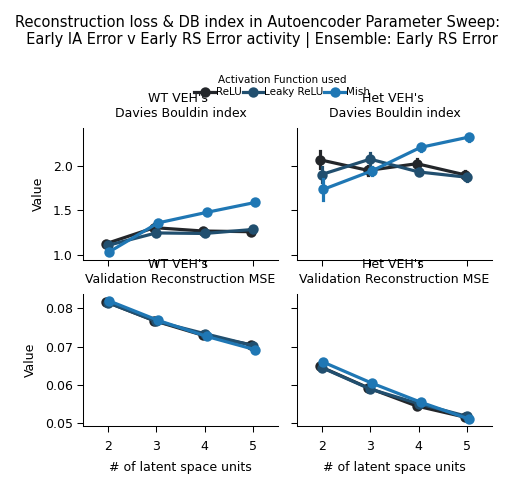

In [33]:
# Faceted pointplot: one panel per genotype
fig = plt.figure(figsize=(8,6),layout = 'constrained')
melt_sweep_df = sweep_results_df.melt(id_vars=['geno', 'activation', 'hidden_size'], 
                                        value_vars=['val_db_index', 'val_loss'], 
                                        var_name='metric', value_name='value')
melt_sweep_df['metric'] = melt_sweep_df['metric'].map({'val_db_index': 'Davies Bouldin index', 'val_loss': 'Validation Reconstruction MSE'})
g = sns.FacetGrid(melt_sweep_df, col='geno',row = 'metric', height=1.5, aspect=1.1, sharey='row')
g.map_dataframe(sns.pointplot, x='hidden_size', y='value', hue='activation', dodge=True, errorbar='se')
g.set_titles("{col_name}'s \n{row_name}")
g.set_axis_labels("# of latent space units", "Value")
# Make room at top for suptitle AND legend
g.figure.subplots_adjust(top=0.8)
handles, labels = g.axes.flat[0].get_legend_handles_labels()
label_rename = {'relu': 'ReLU', 'leaky_relu': 'Leaky ReLU', 'mish': 'Mish'}
new_labels = [label_rename.get(label, label) for label in labels]
# Add legend at top center, between suptitle and plots
g.figure.legend(handles, new_labels, loc='upper center', bbox_to_anchor=(0.55, 0.93),ncol=len(new_labels),title="Activation Function used", frameon=False)
g.figure.suptitle(f"Reconstruction loss & DB index in Autoencoder Parameter Sweep:\n  {comparison.replace("_", " ")} activity | Ensemble: {ensemble.replace("_", " ")}",
                  y = 1.05, 
                  fontsize=7)
plt.savefig(f"sweep_results_{comparison}_{ensemble}.png", dpi=150, bbox_inches='tight')

In [34]:

# Print summary statistics
print("\nSummary: Mean DB Index by Configuration")
summary = sweep_results_df.groupby(['activation', 'hidden_size']).agg({
    'db_index': ['mean', 'std', 'min', 'max'],
    'final_loss': ['mean', 'std']
}).round(4)
print(summary)

# Best configuration
best_idx = sweep_results_df.groupby(['activation', 'hidden_size'])['db_index'].mean().idxmin()
print(f"\nBest configuration: activation={best_idx[0]}, hidden_size={best_idx[1]}")


Summary: Mean DB Index by Configuration


KeyError: "Column(s) ['db_index', 'final_loss'] do not exist"

#### new- resample to get # of cells dropped per concat

In [ ]:
def analyze_dropped_cells(class_matrix_store, comparisons, ensembles, geno_list, 
                          n_frames_to_draw=500, n_iterations=5):
    """
    Analyze which cells are dropped during the inner join for each geno × comparison × ensemble.
    
    Returns:
        dropped_summary_df: Summary with counts per combination
        dropped_details: Dict with actual cell IDs dropped per combination
    """
    results = []
    dropped_details = {}
    
    for comparison in comparisons:
        class_0, class_1 = comparison.split("_v_")
        
        for ensemble in ensembles:
            for geno in geno_list:
                # Track across multiple resampling iterations to capture variability
                iteration_results = []
                all_dropped_ids = set()
                
                for iteration in range(n_iterations):
                    try:
                        # Resample each stage
                        ensemble_resample = resample_ensemble_stage_activity(
                            class_matrix_store, n_frames_to_draw, ensemble, geno,
                            stages_to_resample=[class_0, class_1]
                        )
                        
                        # Get cell IDs before join
                        class_0_ids = set(ensemble_resample[class_0].index)
                        class_1_ids = set(ensemble_resample[class_1].index)
                        
                        # Perform the inner join (same as fast_pack_data_local)
                        concat_matrix = ensemble_resample[class_0].join(ensemble_resample[class_1], how='inner', lsuffix='_c0', rsuffix='_c1')
                        joined_ids = set(concat_matrix.index)
                        # Calculate dropped cells
                        dropped_from_class0 = class_0_ids - joined_ids
                        dropped_from_class1 = class_1_ids - joined_ids
                        all_dropped = (class_0_ids | class_1_ids) - joined_ids
                        all_dropped_ids.update(all_dropped)
                        
                        iteration_results.append({
                            'n_class0': len(class_0_ids),'n_class1': len(class_1_ids),
                            'n_after_join': len(joined_ids),
                            'n_dropped_from_class0': len(dropped_from_class0),'n_dropped_from_class1': len(dropped_from_class1),
                            'n_total_dropped': len(all_dropped),'dropped_ids': all_dropped,})
                        
                    except KeyError as e:
                        # Handle missing data for this combination
                        iteration_results.append({'n_class0': 0, 'n_class1': 0, 'n_after_join': 0,'n_dropped_from_class0': 0, 'n_dropped_from_class1': 0,
                            'n_total_dropped': 0, 'dropped_ids': set(),'error': str(e)})
                
                # Aggregate results across iterations
                valid_results = [r for r in iteration_results if 'error' not in r]
                
                if valid_results:
                    results.append({
                        'comparison': comparison,
                        'ensemble': ensemble,
                        'geno': geno,
                        'class_0': class_0,
                        'class_1': class_1,
                        'n_class0_mean': np.mean([r['n_class0'] for r in valid_results]),
                        'n_class1_mean': np.mean([r['n_class1'] for r in valid_results]),
                        'n_after_join_mean': np.mean([r['n_after_join'] for r in valid_results]),
                        'n_dropped_mean': np.mean([r['n_total_dropped'] for r in valid_results]),
                        'n_dropped_from_class0_mean': np.mean([r['n_dropped_from_class0'] for r in valid_results]),
                        'n_dropped_from_class1_mean': np.mean([r['n_dropped_from_class1'] for r in valid_results]),
                        'pct_dropped': np.mean([r['n_total_dropped'] / max(r['n_class0'], r['n_class1'], 1) * 100 
                                               for r in valid_results]),
                        'n_unique_dropped_ids': len(all_dropped_ids),
                    })
                    
                    # Store dropped IDs
                    key = (comparison, ensemble, geno)
                    dropped_details[key] = {
                        'dropped_ids': list(all_dropped_ids),
                        'class_0_specific': list(class_0_ids - class_1_ids) if valid_results else [],
                        'class_1_specific': list(class_1_ids - class_0_ids) if valid_results else [],
                    }
                else:
                    results.append({
                        'comparison': comparison,
                        'ensemble': ensemble,
                        'geno': geno,
                        'class_0': class_0,
                        'class_1': class_1,
                        'n_class0_mean': 0, 'n_class1_mean': 0, 'n_after_join_mean': 0,
                        'n_dropped_mean': 0, 'n_dropped_from_class0_mean': 0,
                        'n_dropped_from_class1_mean': 0, 'pct_dropped': 0,
                        'n_unique_dropped_ids': 0,
                        'error': 'No valid iterations'
                    })
    
    return pd.DataFrame(results), dropped_details


def print_dropped_cell_summary(dropped_df, dropped_details, show_ids=False):
    """Pretty print the dropped cell analysis results."""
    print("=" * 80)
    print("DROPPED CELLS ANALYSIS SUMMARY")
    print("=" * 80)
    
    for _, row in dropped_df.iterrows():
        print(f"\n{row['comparison']} | Ensemble: {row['ensemble']} | Geno: {row['geno']}")
        print("-" * 60)
        print(f"  {row['class_0']}: {row['n_class0_mean']:.0f} cells")
        print(f"  {row['class_1']}: {row['n_class1_mean']:.0f} cells")
        print(f"  After inner join: {row['n_after_join_mean']:.0f} cells")
        print(f"  Dropped: {row['n_dropped_mean']:.0f} cells ({row['pct_dropped']:.1f}%)")
        print(f"    - From {row['class_0']}: {row['n_dropped_from_class0_mean']:.0f}")
        print(f"    - From {row['class_1']}: {row['n_dropped_from_class1_mean']:.0f}")
        
        if show_ids:
            key = (row['comparison'], row['ensemble'], row['geno'])
            if key in dropped_details and dropped_details[key]['dropped_ids']:
                ids = dropped_details[key]['dropped_ids'][:10]  # Show first 10
                print(f"  Sample dropped IDs: {ids}")
                if len(dropped_details[key]['dropped_ids']) > 10:
                    print(f"    ... and {len(dropped_details[key]['dropped_ids']) - 10} more")

In [ ]:
# Define combinations of interest
comparisons_to_analyze = [
    'Early_IA_Error_v_Early_RS_Error',
    'Early_IA_Correct_v_Early_RS_Correct',
]

ensembles_to_analyze = [
    'Early_IA_Correct',
    'Early_IA_Error', 
    'Early_RS_Correct',
    'Early_RS_Error',
]

geno_list_to_analyze = geno_order  # Use all genotypes

# Run the analysis
print("Analyzing dropped cells across all combinations...")
print(f"Comparisons: {comparisons_to_analyze}")
print(f"Ensembles: {ensembles_to_analyze}")
print(f"Genotypes: {geno_list_to_analyze}")
print()

dropped_df, dropped_details = analyze_dropped_cells(
    class_matrix_store=class_matrix_store,
    comparisons=comparisons_to_analyze,
    ensembles=ensembles_to_analyze,
    geno_list=geno_list_to_analyze,
    n_frames_to_draw=500,
    n_iterations=3  # Average over 3 resampling iterations
)

# Print summary
print_dropped_cell_summary(dropped_df, dropped_details, show_ids=True)

In [ ]:
dropped_df

In [ ]:
# Visualize dropped cells and save results
fig, axes = plt.subplots(1, 2, figsize=(5, 2), layout='constrained', sharey= True)

# Plot 1: Heatmap of % dropped by ensemble × geno (averaged across comparisons)
for c, comp in enumerate(comparisons_to_analyze):
    ax = axes[c]
    comp_df = dropped_df.loc[dropped_df['comparison'] == comp]
    pivot_pct = comp_df.pivot(index=['ensemble'], columns='geno', values='pct_dropped').loc[:, geno_order]
    sns.heatmap(pivot_pct, annot=True, fmt='.0f', cmap='Reds', ax=ax, cbar = False)
    set_labels(ax = ax, label_dict = {'x':'Genotype', 'y':'Ensemble', 
                                      'title':f'% of Ensemble Cells Dropped when Decoding: \n {comp.replace("_", " ")}'}) 
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)

axes[0].set_yticklabels(axes[0].get_yticklabels(), rotation=0)

plt.savefig(f"dropped_cells_analysis_{date_tag}.png", dpi=150, bbox_inches='tight')
# Save detailed results
dropped_df.to_csv(f"dropped_cells_summary_{date_tag}.csv", index=False)
print(f"\nSaved: dropped_cells_summary_{date_tag}.csv")

In [ ]:
def resample_ensemble_stage_activity(class_matrix_store,
                                     n_frames_to_draw:int=500,
                                     ensemble:str = "",
                                     geno:str="",
                                     stages_to_resample:list  = ['Early_IA_Correct', 'Early_RS_Correct', 'Early_IA_Error', 'Early_RS_Error'],
                                     **kwargs):
    '''To iterate over specified stages and return dict containing N resampled frame for each stage. Requires 'resample_into_class_matrix'
    '''
    ensemble_resample_in_phase_dict = {}
    for class_name in stages_to_resample: #store the versions for this bootstrap run
        class_mat = resample_into_class_matrix(class_matrix_store,n_frames_to_draw,ensemble, class_name, geno)
        ensemble_resample_in_phase_dict[class_name] = class_mat
        
    return ensemble_resample_in_phase_dict